# The whole module on real data

Every other notebook in this series runs on `ov.datasets.flow_demo()`, which is
simulated — deliberately, because a simulation is the only way to *show* what
spillover did, and the only way to check a gate against the answer.

This one runs on two real, published, openly-licensed experiments. Nothing here
is arranged for convenience, and three things break that never break on
simulated data:

1. the top of scale is **not** 262,144 — it is whatever the instrument wrote
   into `$PnR`, and it differs between instruments *and between channels*;
2. the logicle `W` that looked fine on simulated data crushes the negative
   population into the axis, because real detector noise is far wider;
3. the populations overlap, so a gate is a judgement call rather than a line
   between two clean clouds.

## The two datasets, and why it takes two

No openly-licensed cytometry dataset carries a full CD3/CD4/CD8/CD19 hierarchy
**and** a real spillover matrix **and** the FSC-H a singlet gate needs. Each of
these has two of the three, so the notebook uses both and is explicit about
which lesson each one supports.

| | `flow_pbmc_fortessa` | `flow_pbmc_spectral` |
|---|---|---|
| Instrument | BD LSRFortessa (conventional) | Cytek Aurora (full spectrum) |
| Spillover | **real 13×13, uncompensated** | 9×9 **identity** — unmixed at acquisition |
| Singlet gate | ✗ no FSC-H | **✓ FSC-A + FSC-H** |
| B cells | ✗ no CD19 | **✓ CD19** |
| Samples | 32 files, identical panel | 6 donors |

**Citations** — both are CC-BY-4.0 and are downloaded from their original
repositories rather than re-hosted:

- Kim, Edy (2024). *Immunophenotyping of peripheral blood mononuclear cells
  after out-of-hospital cardiac arrest.* Zenodo.
  [10.5281/zenodo.14311616](https://doi.org/10.5281/zenodo.14311616)
- Gootjes C, Zwaginga JJ, Nikolic T, Roep BO (2026). *Limited efficacy of a
  therapeutic anti-CD40 monoclonal antibody to inhibit activated CD4 T cell
  autoimmunity in vitro.* PLOS ONE.
  [10.1371/journal.pone.0351131](https://doi.org/10.1371/journal.pone.0351131)

The loaders cache into `./data`, so the download happens once.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov

adata = ov.datasets.flow_pbmc_fortessa(n_per_group=2, max_events=25000)
adata

/Users/fernandozeng/miniforge3/envs/omictest/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔍 Downloading data to ./data/96_Healthy_Anti-Nectin2_Isotype_3.fcs
⚠️ File ./data/96_Healthy_Anti-Nectin2_Isotype_3.fcs already exists
🔍 Downloading data to ./data/97_Healthy_Anti-Nectin2_Isotype_4.fcs
⚠️ File ./data/97_Healthy_Anti-Nectin2_Isotype_4.fcs already exists
🔍 Downloading data to ./data/108_CA_Anti-Nectin2_Isotype_3.fcs
⚠️ File ./data/108_CA_Anti-Nectin2_Isotype_3.fcs already exists


🔍 Downloading data to ./data/110_CA_Anti-Nectin2_Isotype_5.fcs
⚠️ File ./data/110_CA_Anti-Nectin2_Isotype_5.fcs already exists
100,000 events x 16 channels from 4 files
Kim, Edy (2024). Immunophenotyping of peripheral blood mononuclear cells after out-of-hospital cardiac arrest. Zenodo. https://doi.org/10.5281/zenodo.14311616 (CC-BY-4.0)


AnnData object with n_obs × n_vars = 100000 × 16
    obs: 'sample', 'group', 'source_file'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnG', 'PnR'
    uns: 'fcs', 'dataset'

## The top of scale comes from the file

`ov.flow.Linear(t=262144)` is what a BD instrument happens to use. It is not a
constant of nature, and hard-coding it is the first thing that breaks when a
file from another cytometer arrives. `read_fcs` keeps `$PnR` — the top of scale
the acquisition software declared — per channel.

In [2]:
adata.var[["channel", "marker", "PnR"]]

                     channel     marker       PnR
FSC-A                  FSC-A             262144.0
SSC-A                  SSC-A             262144.0
CD3                   FITC-A        CD3  262144.0
Tim3                    PE-A       Tim3  262144.0
Nectin2        PerCP-Cy5-5-A    Nectin2  262144.0
IL10                PE-Cy7-A       IL10  262144.0
IFNg                   APC-A       IFNg  262144.0
TNFa               APC-Cy7-A       TNFa  262144.0
CD4                  BV421-A        CD4  262144.0
CD8                 AmCyan-A        CD8  262144.0
TIGIT                BV605-A      TIGIT  262144.0
CD14                 BV650-A       CD14  262144.0
CD16                 BV711-A       CD16  262144.0
CD56                 BV786-A       CD56  262144.0
LIVE DEAD  Alexa Fluor 350-A  LIVE DEAD  262144.0
Time                    Time             262144.0

In [3]:
# Build the transforms from the file, not from a constant.
T = float(adata.var.loc["FSC-A", "PnR"])
lin = ov.flow.Linear(t=T)
print(f"scatter top of scale from $PnR: {T:,.0f}")

scatter top of scale from $PnR: 262,144


## The spillover matrix is real here

93 of the 156 off-diagonal entries are non-zero and the largest is 0.83 — that
is, one detector picks up 83% as much signal from the *wrong* fluorochrome as
from its own. This is why the compensation step exists.

13x13 matrix, 93/156 off-diagonal terms non-zero, largest 0.832


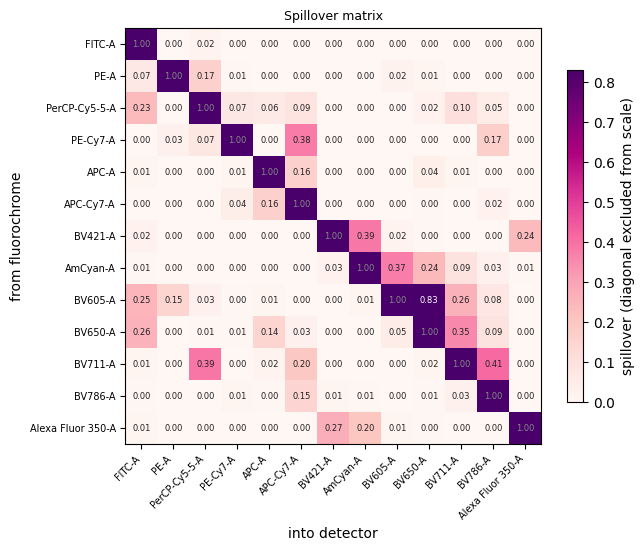

In [4]:
spill = adata.uns["fcs"]["spillover"]
off = spill.to_numpy()[~np.eye(spill.shape[0], dtype=bool)]
print(f"{spill.shape[0]}x{spill.shape[1]} matrix, "
      f"{int((off != 0).sum())}/{off.size} off-diagonal terms non-zero, "
      f"largest {off.max():.3f}")
ov.flow.spillover_heatmap(adata, figsize=(6.6, 5.4))
None

### Compensating

`compensate` uses the file's own matrix. Keep an uncompensated copy — the
comparison is the whole point, and the operation is refused if run twice.

In [5]:
sp = spill.to_numpy().copy()
np.fill_diagonal(sp, 0.0)
i, j = np.unravel_index(np.argmax(sp), sp.shape)
src_det, dst_det = spill.index[i], spill.columns[j]
det2marker = dict(zip(adata.var["channel"], adata.var.index))
src, dst = det2marker[src_det], det2marker[dst_det]
print(f"worst pair: {src} ({src_det}) spills {sp[i, j]:.1%} into {dst} ({dst_det})")

raw = adata.copy()
ov.flow.compensate(adata)

worst pair: TIGIT (BV605-A) spills 83.2% into CD14 (BV650-A)


AnnData object with n_obs × n_vars = 100000 × 16
    obs: 'sample', 'group', 'source_file'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnG', 'PnR'
    uns: 'fcs', 'dataset', 'flow'
    layers: 'uncompensated'

## The transform has to be fitted to the data

Before looking at anything, the display scale has to be fitted — and this is the
part a simulated tutorial cannot teach honestly. `W` sets how wide the logicle's
linear region is, and the value that looked right on simulated data is far too
narrow for a real detector: real compensated negatives run to tens of thousands
of units below zero, not tens. (Fit it *after* compensation, since compensation
is what creates most of those negatives.)

There is a published estimator for it.

In [6]:
def auto_w(values, T, M=4.5):
    """The Parks/Moore auto-logicle width.

    W = (M - log10(T / |r|)) / 2, with r the 5th percentile of the NEGATIVE
    values — i.e. make the linear region just wide enough to hold the noise the
    detector actually produced. Published in Parks, Roederer & Moore (2006),
    Cytometry A 69:541, the same paper the logicle scale comes from.
    """
    negatives = values[values < 0]
    if negatives.size < 10:
        return 0.5                      # nothing below zero: nothing to make room for
    r = np.percentile(negatives, 5)
    w = (M - np.log10(T / abs(r))) / 2.0
    return float(np.clip(w, 0.1, M / 2 - 0.1))


In [7]:
markers = ["CD3", "CD4", "CD8", "CD14", "CD16", "CD56", "LIVE DEAD"]
rows = []
for m in markers:
    v = adata[:, m].X.ravel()
    Tm = float(adata.var.loc[m, "PnR"])
    rows.append({"marker": m, "$PnR": Tm,
                 "5th pct of negatives": np.percentile(v[v < 0], 5) if (v < 0).any() else np.nan,
                 "% below zero": (v < 0).mean(),
                 "W": auto_w(v, Tm)})
widths = pd.DataFrame(rows).set_index("marker")
widths.style.format({"$PnR": "{:,.0f}", "5th pct of negatives": "{:,.0f}",
                     "% below zero": "{:.1%}", "W": "{:.2f}"})

,$PnR,5th pct of negatives,% below zero,W
marker,,,,
CD3,"262,144","-5,594",46.7%,1.41
CD4,"262,144",-155,28.3%,0.64
CD8,"262,144",-511,7.2%,0.89
CD14,"262,144","-4,288",78.0%,1.36
CD16,"262,144",-102,28.6%,0.55
CD56,"262,144",-118,34.3%,0.58
LIVE DEAD,"262,144",-122,29.3%,0.58


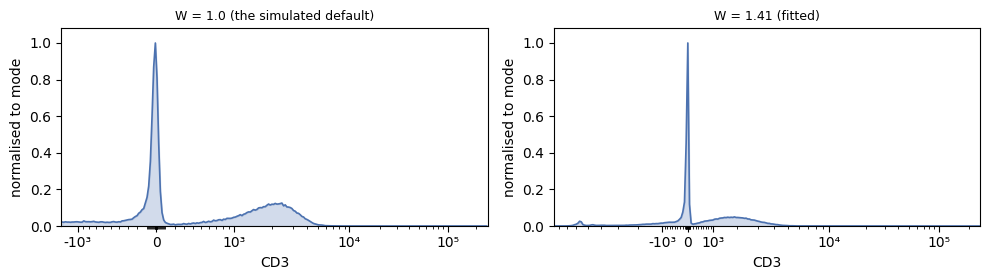

In [8]:
tr = {m: ov.flow.Logicle(t=float(adata.var.loc[m, "PnR"]), m=4.5,
                         w=widths.loc[m, "W"], a=0.0)
      for m in markers}

# What the simulated notebooks used, for comparison.
lg_rough = ov.flow.Logicle(t=T, m=4.5, w=1.0, a=0.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.9))
ov.flow.histogram(adata, "CD3", transforms={"CD3": lg_rough}, ax=axes[0],
                  title="W = 1.0 (the simulated default)")
ov.flow.histogram(adata, "CD3", transforms={"CD3": tr["CD3"]}, ax=axes[1],
                  title=f"W = {widths.loc['CD3', 'W']:.2f} (fitted)")
plt.tight_layout()

### Now the before-and-after is readable

The same pair, on the fitted scale. Uncompensated, `{src}` leaking into the
`{dst}` detector produces the classic diagonal smear — every `{src}`-bright event
looks slightly `{dst}`-positive in proportion to how bright it is.

Compensated, the smear is gone. What replaces it is a fan of *negative* values,
and that is not an error: subtracting 83% of one detector from another pushes
dim events well below zero. It is the price of a correction that large, and it is
the reason the axis has to be biexponential.

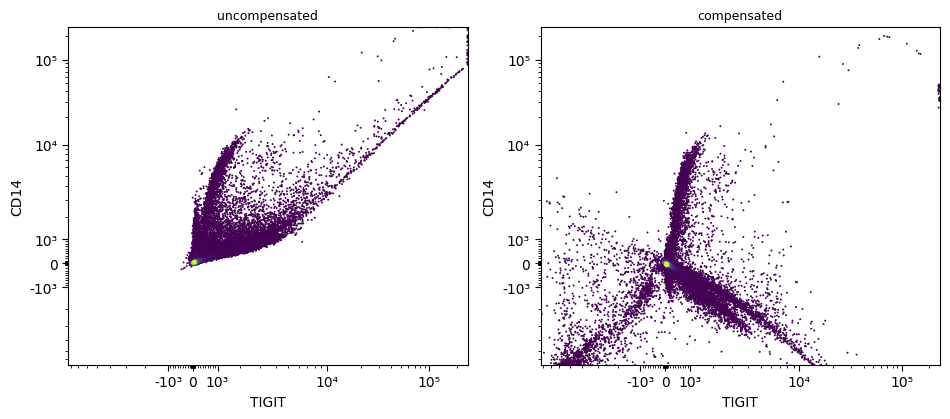

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.3))
pair_tr = {src: tr[src] if src in tr else ov.flow.Logicle(
               t=float(adata.var.loc[src, "PnR"]), m=4.5,
               w=auto_w(adata[:, src].X.ravel(), float(adata.var.loc[src, "PnR"])), a=0.0),
           dst: tr[dst] if dst in tr else ov.flow.Logicle(
               t=float(adata.var.loc[dst, "PnR"]), m=4.5,
               w=auto_w(adata[:, dst].X.ravel(), float(adata.var.loc[dst, "PnR"])), a=0.0)}
for ax, sample, title in ((axes[0], raw, "uncompensated"),
                          (axes[1], adata, "compensated")):
    ov.flow.biaxial(sample, src, dst, transforms=pair_tr, ax=ax,
                    title=title, max_events=40000)
plt.tight_layout()

The negative population is a population. At the default width it is a
spike against the axis; fitted, it is a distribution you can put a threshold
next to.

## The gating strategy

Scatter, then viability, then lineage. Thresholds are written as data values and
converted with `at()`, never as the scale-space numbers they happen to equal.

In [10]:
def at(marker, value):
    """A data value expressed on that marker's own scale."""
    return float(tr[marker].apply(np.array([float(value)]))[0])

def scat(value):
    return float(lin.apply(np.array([float(value)]))[0])

cells_gate = ov.flow.PolygonGate(
    name="Cells", dims=("FSC-A", "SSC-A"),
    transforms={"FSC-A": lin, "SSC-A": lin},
    vertices=np.array([[scat(28000), scat(2000)], [scat(28000), scat(72000)],
                       [scat(95000), scat(130000)], [scat(165000), scat(130000)],
                       [scat(165000), scat(30000)], [scat(80000), scat(2000)]]))

live = ov.flow.RectangleGate(
    name="Live", dims=("LIVE DEAD",), transforms={"LIVE DEAD": tr["LIVE DEAD"]},
    bounds=((None, at("LIVE DEAD", 400)),))

cd3 = ov.flow.RectangleGate(
    name="T cells", dims=("CD3",), transforms={"CD3": tr["CD3"]},
    bounds=((at("CD3", 400), None),))

quad = ov.flow.QuadrantGate(
    name="CD4/CD8", dims=("CD4", "CD8"),
    transforms={"CD4": tr["CD4"], "CD8": tr["CD8"]},
    dividers=(at("CD4", 120), at("CD8", 250)),
    quadrant_names=("DN T", "CD4 T", "CD8 T", "DP T"))

not_t = ov.flow.RectangleGate(
    name="CD3-", dims=("CD3",), transforms={"CD3": tr["CD3"]},
    bounds=((None, at("CD3", 400)),))

nk = ov.flow.RectangleGate(
    name="NK", dims=("CD56",), transforms={"CD56": tr["CD56"]},
    bounds=((at("CD56", 300), None),))

mono = ov.flow.RectangleGate(
    name="Monocytes", dims=("CD14",), transforms={"CD14": tr["CD14"]},
    bounds=((at("CD14", 800), None),))

gs = ov.flow.GatingStrategy("PBMC immunophenotyping")
gs.add_gate(cells_gate)
gs.add_gate(live,  parent="Cells")
gs.add_gate(cd3,   parent="Live")
gs.add_gate(quad,  parent="T cells")
gs.add_gate(not_t, parent="Live")
gs.add_gate(nk,    parent="CD3-")
gs.add_gate(mono,  parent="CD3-")
print(gs.tree())

root
  └ Cells
    └ Live
      └ T cells
        └ CD4/CD8
        └ DN T
        └ CD4 T
        └ CD8 T
        └ DP T
      └ CD3-
        └ NK
        └ Monocytes


In [11]:
res = gs.apply(adata)
res.stats()

   population   parent  count  parent_count  freq_parent  freq_total  low_n
0        CD3-     Live  18946         55716     0.340046     0.18946  False
1       CD4 T  T cells  11531         36770     0.313598     0.11531  False
2     CD4/CD8  T cells  36770         36770     1.000000     0.36770  False
3       CD8 T  T cells  10489         36770     0.285260     0.10489  False
4       Cells     root  56321        100000     0.563210     0.56321  False
5        DN T  T cells  14682         36770     0.399293     0.14682  False
6        DP T  T cells     68         36770     0.001849     0.00068   True
7        Live    Cells  55716         56321     0.989258     0.55716  False
8   Monocytes     CD3-    748         18946     0.039481     0.00748  False
9          NK     CD3-   2681         18946     0.141507     0.02681  False
10    T cells     Live  36770         55716     0.659954     0.36770  False

In [12]:
# What did the viability gate actually remove? On a fresh sample the
# answer can be "almost nothing", and that is worth stating rather than
# implying the gate did work it did not do.
removed = int(res.masks["Cells"].sum() - res.masks["Live"].sum())
print(f"viability gate removed {removed:,} of {int(res.masks['Cells'].sum()):,} "
      f"events ({removed / res.masks['Cells'].sum():.1%})")

viability gate removed 605 of 56,321 events (1.1%)


Two things in that table are worth stopping on.

`low_n` is doing its job on `DP T` — a frequency quoted off a few dozen events
is not a measurement, and the column says so rather than leaving the reader to
notice.

And `DN T` is about **40% of T cells**, where healthy peripheral blood is
1–5%. That is not a rounding error, it is a factor of ten, and it is the first
thing a reviewer would ask about. Hold onto it; the batch section below explains
it, and the explanation is not "move the gate".

## Seeing it

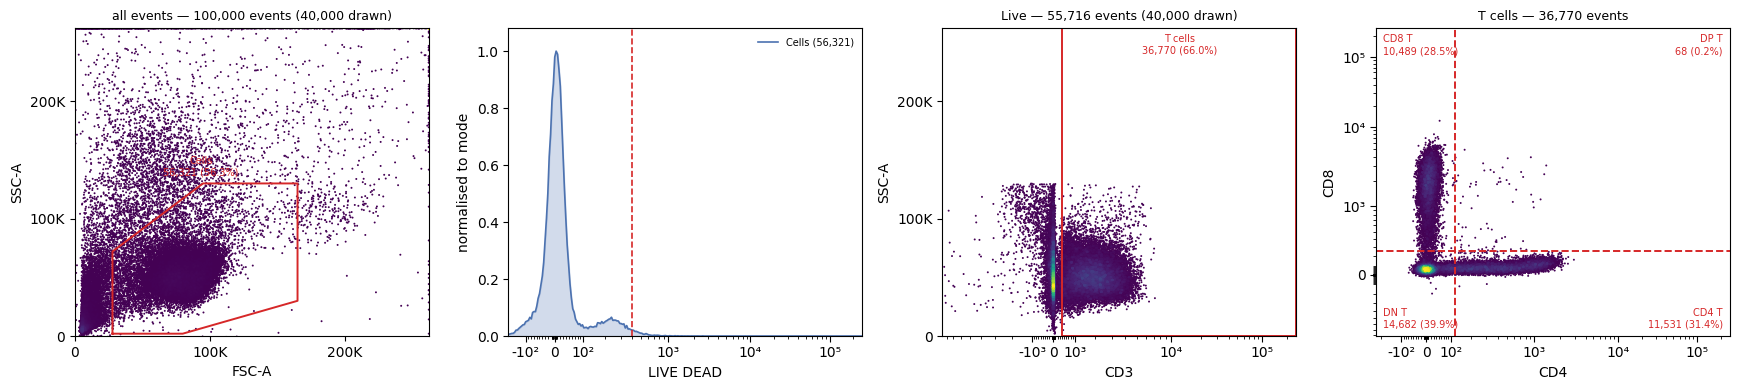

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(17.5, 4.0))
ov.flow.biaxial(adata, "FSC-A", "SSC-A", gates=[cells_gate], result=res,
                ax=axes[0], max_events=40000)
ov.flow.histogram(adata, "LIVE DEAD", gates=[live], result=res,
                  transforms={"LIVE DEAD": tr["LIVE DEAD"]},
                  populations=["Cells"], ax=axes[1])
ov.flow.biaxial(adata, "CD3", "SSC-A", gates=[cd3],
                transforms={"CD3": tr["CD3"], "SSC-A": lin},
                result=res, population="Live", ax=axes[2], max_events=40000)
ov.flow.biaxial(adata, "CD4", "CD8", gates=[quad], result=res,
                population="T cells", ax=axes[3], max_events=40000)
plt.tight_layout()

This is what real data looks like: the CD4 and CD8 arms are there and
they are separable, but they are not the two tidy islands a simulation produces.
The CD4 arm in particular sits low — that is the panel, not the gate.

### Back-gating: is the NK gate finding NK cells?

CD56 is expressed on some T cells too, so a CD56 threshold under a CD3-negative
parent should land in the lymphocyte scatter region. If it did not, the gate
would be picking up debris.

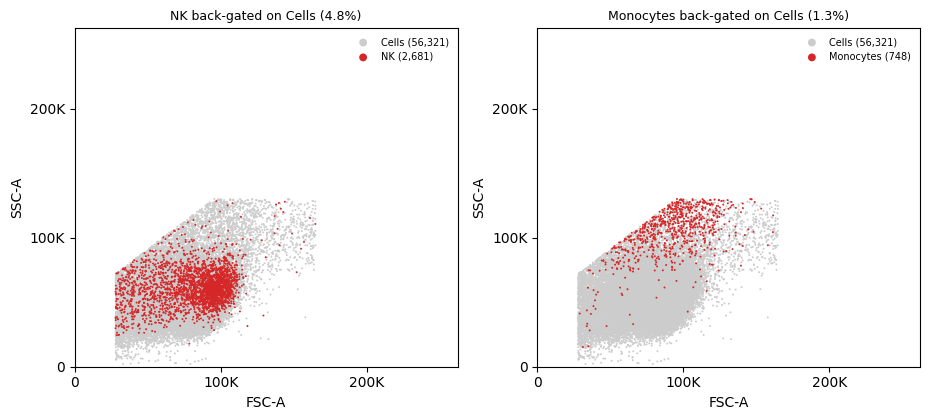

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.3))
ov.flow.backgate(adata, "FSC-A", "SSC-A", result=res, population="NK",
                 parent="Cells", transforms={"FSC-A": lin, "SSC-A": lin},
                 ax=axes[0])
ov.flow.backgate(adata, "FSC-A", "SSC-A", result=res, population="Monocytes",
                 parent="Cells", transforms={"FSC-A": lin, "SSC-A": lin},
                 ax=axes[1])
plt.tight_layout()

Monocytes land high on both scatter axes and NK cells in the
lymphocyte cloud — which is what those populations are, and is the check that
the thresholds are on real biology rather than on noise.

## The hierarchy

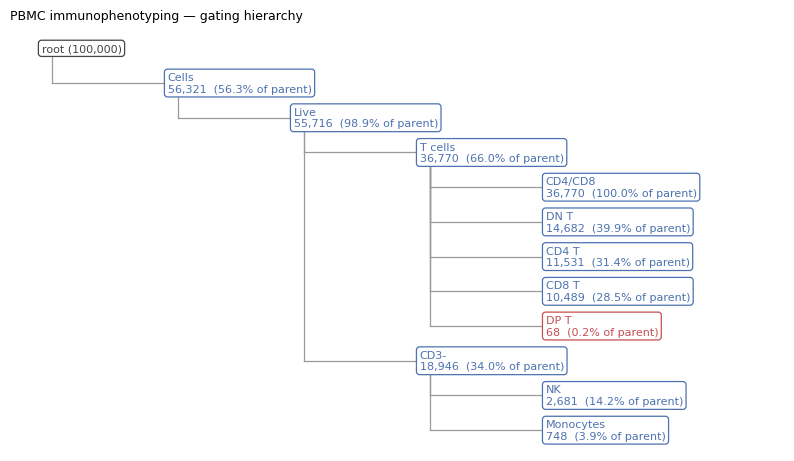

In [15]:
ov.flow.hierarchy(gs, result=res, figsize=(10, 5.5))
None

## One strategy, the whole batch

The reason the strategy is an object. Four files — two healthy donors, two after
out-of-hospital cardiac arrest — through the *same* gates.

In [16]:
rows = {}
for sample in adata.obs["sample"].cat.categories:
    sub = adata[adata.obs["sample"] == sample].copy()
    r = gs.apply(sub, write_obs=False)
    rows[sample] = r.stats().set_index("population")["freq_parent"]
freqs = pd.concat(rows, axis=1)
freqs.style.format("{:.1%}")

,108_CardiacArrest,110_CardiacArrest,96_Healthy,97_Healthy
population,,,,
CD3-,47.9%,45.7%,33.0%,23.3%
CD4 T,41.7%,46.6%,64.7%,0.0%
CD4/CD8,100.0%,100.0%,100.0%,100.0%
CD8 T,36.7%,35.8%,29.6%,22.9%
Cells,33.3%,43.5%,65.4%,83.1%
DN T,21.5%,17.1%,5.3%,77.0%
DP T,0.1%,0.5%,0.3%,0.0%
Live,96.0%,98.6%,99.8%,99.5%
Monocytes,7.6%,0.6%,7.1%,1.0%


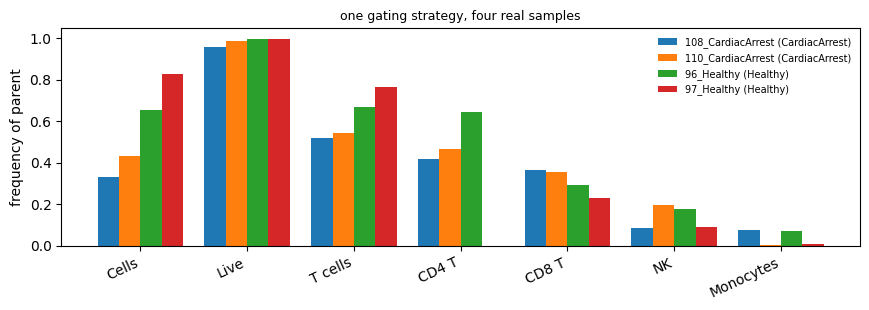

In [17]:
order = ["Cells", "Live", "T cells", "CD4 T", "CD8 T", "NK", "Monocytes"]
groups = dict(zip(adata.obs["sample"], adata.obs["group"]))
fig, ax = plt.subplots(figsize=(8.8, 3.2))
x, w = np.arange(len(order)), 0.2
for i, s in enumerate(freqs.columns):
    ax.bar(x + (i - 1.5) * w, freqs.loc[order, s], w,
           label=f"{s} ({groups[s]})")
ax.set_xticks(x, labels=order, rotation=25, ha="right")
ax.set_ylabel("frequency of parent")
ax.legend(fontsize=7, frameon=False)
ax.set_title("one gating strategy, four real samples", fontsize=9)
plt.tight_layout()

### And there is the 40%

Look along the `DN T` row rather than at the pooled number.

In [18]:
dn = freqs.loc["DN T"].sort_values()
pd.DataFrame({"DN T (% of T cells)": dn.map("{:.1%}".format),
              "group": [groups[s] for s in dn.index]})

                  DN T (% of T cells)          group
96_Healthy                       5.3%        Healthy
110_CardiacArrest               17.1%  CardiacArrest
108_CardiacArrest               21.5%  CardiacArrest
97_Healthy                      77.0%        Healthy

One sample is not like the others. The pooled 40% was never a property
of the biology — it is one file with 78% double-negative T cells dragging an
average that also contains a sample at 5%, which is exactly the healthy figure.

The likely cause is a failed or weak CD4/CD8 stain in that one tube, and the
useful response is to go back to the acquisition and find out — not to move the
divider until the average looks respectable. **This tutorial does not silently
drop the sample**, because a reader who only ever sees clean data learns nothing
about what to do with dirty data.

It is also the argument for the whole design of `GatingStrategy`. The same gates
ran on four files independently; had they been applied to the pooled matrix and
reported once, the failure would have been invisible.

With two donors per group the rest of this is a demonstration of the mechanism,
not a result — four samples cannot support a claim about cardiac arrest. The
dataset has 32 files if you want to go further: `n_per_group` up to 3 here, and
the full record on Zenodo.

## Saving the strategy

Everything above is a portable object. Written to Gating-ML 2.0, it opens in
FlowJo, Cytobank or flowCore.

In [19]:
ov.flow.write_gatingml(gs, "pbmc_strategy.xml")
back = ov.flow.read_gatingml("pbmc_strategy.xml")
check = back.apply(adata.copy(), write_obs=False)
print(f"{len(back)} gates read back")
print("every population identical after the round trip:",
      all(np.array_equal(res.masks[k], check.masks[k]) for k in res.masks))

7 gates read back
every population identical after the round trip: True


## FlowSOM on the gated T cells

Clustering after gating, which is the order that works: the dead cells and the
debris are already gone, so the metaclusters are phenotypes rather than
artefacts.

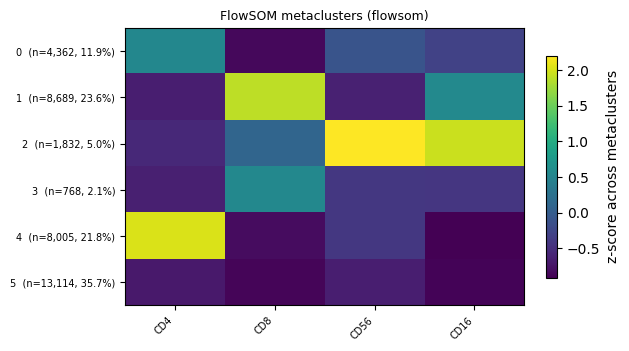

In [20]:
t_cells = adata[res.masks["T cells"]].copy()
t_cells.layers["logicle"] = np.column_stack(
    [tr[m].apply(t_cells[:, m].X.ravel()) if m in tr
     else lin.apply(t_cells[:, m].X.ravel())
     for m in t_cells.var.index])

ov.flow.flowsom(t_cells, n_clusters=6, grid=(8, 8), n_epochs=12,
                layer="logicle", markers=["CD4", "CD8", "CD56", "CD16"],
                random_state=0)
ov.flow.flowsom_heatmap(t_cells, layer="logicle",
                        markers=["CD4", "CD8", "CD56", "CD16"],
                        figsize=(5.6, 3.6))
None

In [21]:
# Do the metaclusters agree with the gates that were drawn by hand?
pd.crosstab(t_cells.obs["flowsom"],
            pd.Series(np.where(res.masks["CD4 T"][res.masks["T cells"]], "CD4 T",
                      np.where(res.masks["CD8 T"][res.masks["T cells"]], "CD8 T",
                               "other")), index=t_cells.obs_names, name="gate"))

gate     CD4 T  CD8 T  other
flowsom                     
0         3396      2    964
1            0   8665     24
2          140    881    811
3            0    760      8
4         7995      0     10
5            0    181  12933

## What this dataset cannot do

No CD19, so B cells are only "not everything else". No FSC-H, so **no doublet
discrimination at all** — every count above includes whatever doublets the
sample contained, and there is nothing in the file that could exclude them.

That is not a flaw in the analysis; it is a limit of the acquisition, and the
honest thing is to say so rather than to draw a singlet gate on axes that cannot
support one. The second dataset can.

In [22]:
spectral = ov.datasets.flow_pbmc_spectral(n_donors=1, max_events=60000)
spectral.var[["channel", "marker", "PnR"]]

⚠️ File ./data/pone.0351131.s002.zip already exists


60,000 events x 16 channels from 1 donor(s)
Gootjes C, Zwaginga JJ, Nikolic T, Roep BO (2026). Limited efficacy of a therapeutic anti-CD40 monoclonal antibody to inhibit activated CD4 T cell autoimmunity in vitro. PLOS ONE. https://doi.org/10.1371/journal.pone.0351131 (CC-BY-4.0)


                   channel marker        PnR
Time                  Time         2293297.0
SSC-H                SSC-H         4194304.0
SSC-A                SSC-A         4194304.0
FSC-H                FSC-H         4194304.0
FSC-A                FSC-A         4194304.0
SSC-B-H            SSC-B-H         4194304.0
SSC-B-A            SSC-B-A         4194304.0
CD56               BV510-A   CD56  4194304.0
CD15               BV605-A   CD15  4194304.0
CD4                BV650-A    CD4  4194304.0
CD14     Alexa Fluor 488-A   CD14  4194304.0
CD19                  PE-A   CD19  4194304.0
CD8         PE-Dazzle594-A    CD8  4194304.0
CD16              PE-Cy7-A   CD16  4194304.0
CD40                 APC-A   CD40  4194304.0
CD3              APC-Cy7-A    CD3  4194304.0

Note `$PnR` again: this instrument runs to 2,293,297 and 4,194,304
depending on the channel, not 262,144. A transform built from a hard-coded top
of scale would put every event in the wrong place.

4,194,304 vs the BD instrument's 262,144
FSC-H / FSC-A: p5=0.65, p25=0.83, p50=0.97, p75=1.03, p95=1.08


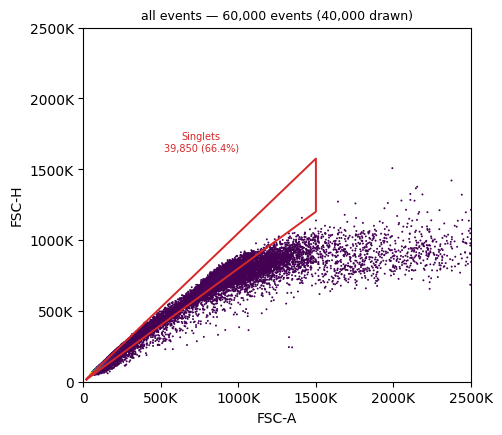

In [23]:
Ts = float(spectral.var.loc["FSC-A", "PnR"])
lin_s = ov.flow.Linear(t=Ts)
print(f"{Ts:,.0f} vs the BD instrument's {T:,.0f}")

# A singlet gate is a band around FSC-H / FSC-A ~ 1. Read the band off the data
# rather than guessing at vertices: a doublet has the same pulse area spread
# over a longer time, so its height-to-area ratio drops.
A = spectral[:, "FSC-A"].X.ravel()
H = spectral[:, "FSC-H"].X.ravel()
ratio = H / np.maximum(A, 1)
print("FSC-H / FSC-A: " + ", ".join(
    f"p{p}={np.percentile(ratio, p):.2f}" for p in (5, 25, 50, 75, 95)))

lo, hi, a0, a1 = 0.80, 1.05, 20_000.0, 1_500_000.0
def sc(v):
    return float(lin_s.apply(np.array([float(v)]))[0])

singlets = ov.flow.PolygonGate(
    name="Singlets", dims=("FSC-A", "FSC-H"),
    transforms={"FSC-A": lin_s, "FSC-H": lin_s},
    vertices=np.array([[sc(a0), sc(lo * a0)], [sc(a1), sc(lo * a1)],
                       [sc(a1), sc(hi * a1)], [sc(a0), sc(hi * a0)]]))
gs_s = ov.flow.GatingStrategy("spectral").add_gate(singlets)
res_s = gs_s.apply(spectral, write_obs=False)

ov.flow.biaxial(spectral, "FSC-A", "FSC-H", gates=[singlets], result=res_s,
                figsize=(5.0, 4.6), max_events=40000,
                xlim=(0, sc(2_500_000)), ylim=(0, sc(2_500_000)))
None

The doublets are the events below the diagonal — same pulse area, less height —
and this is the plot that removes them. Note the axes are zoomed: FSC-A runs to
4.2 million on this instrument and the population occupies the bottom sixth of
it, so the default full-scale view would show a dot in the corner.

The Fortessa dataset has no FSC-H channel at all, so this gate is simply
unavailable there — every count in the first half of this notebook includes
whatever doublets those tubes contained.

### And its spillover is the identity

A full-spectrum instrument unmixes at acquisition. The `$SPILLOVER` keyword is
present and is the identity matrix, so there is nothing to compensate — running
`compensate()` here would be a ritual, not a correction.

In [24]:
sp_s = spectral.uns["fcs"]["spillover"]
print(f"{sp_s.shape[0]}x{sp_s.shape[1]}, identity:",
      np.allclose(sp_s.to_numpy(), np.eye(sp_s.shape[0]), atol=1e-5))
print(f"largest off-diagonal term: "
      f"{np.abs(sp_s.to_numpy() - np.eye(sp_s.shape[0])).max():.2g}")

9x9, identity: True
largest off-diagonal term: 1e-06


### The full lineage panel

CD19 is here, so the B-cell arm is a gate rather than an inference.

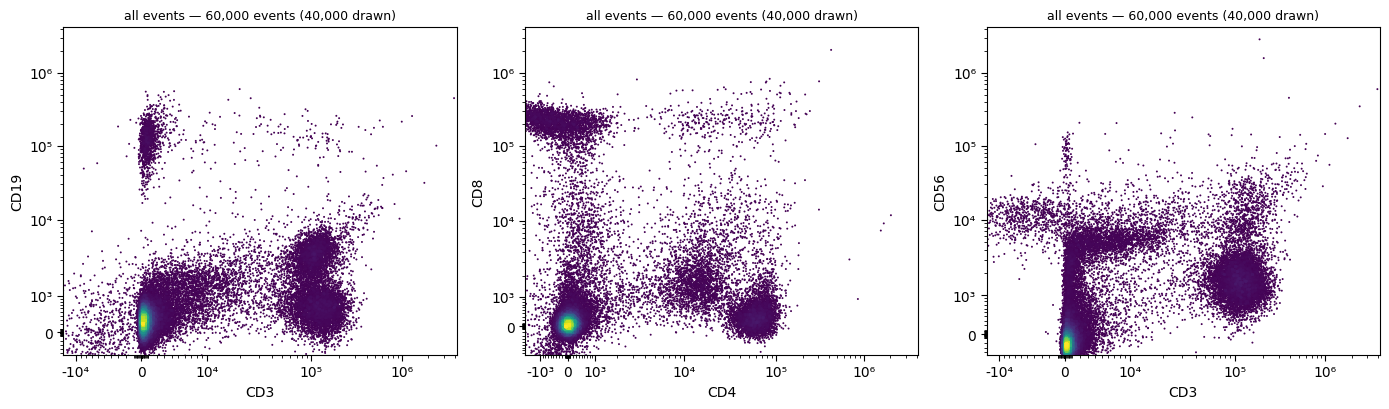

In [25]:
markers_s = ["CD3", "CD4", "CD8", "CD19", "CD14", "CD16", "CD56"]
tr_s = {m: ov.flow.Logicle(t=float(spectral.var.loc[m, "PnR"]), m=4.5,
                           w=auto_w(spectral[:, m].X.ravel(),
                                    float(spectral.var.loc[m, "PnR"])), a=0.0)
        for m in markers_s}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (a_, b_) in zip(axes, [("CD3", "CD19"), ("CD4", "CD8"), ("CD3", "CD56")]):
    ov.flow.biaxial(spectral, a_, b_, transforms={a_: tr_s[a_], b_: tr_s[b_]},
                    ax=ax, max_events=40000)
plt.tight_layout()

## Summary

| Notebook | Data | What it can teach |
|---|---|---|
| [01](t_flow_01_reading_and_compensation.ipynb)–[04](t_flow_04_flowsom.ipynb) | simulated | the mechanics, and checking a gate against the answer |
| 05 | real | what the file actually contains, and what it does not |

Three things this notebook could show and the simulated ones could not:

1. **`$PnR`, not 262144.** Two instruments, three different tops of scale, one
   of them per-channel. A hard-coded `t` is a bug waiting for the next file.
2. **`W` is fitted, not chosen.** Real detector noise is orders of magnitude
   wider than a simulation's, and the published estimator is four lines.
3. **Some questions the data cannot answer.** No FSC-H means no doublet gate,
   and the right response is to say so — not to draw one anyway.

And one thing that only shows up when you actually look: a pooled frequency can
be a fiction. 40% double-negative T cells across four files turned out to be one
file at 78% and another at 5%. Gating each sample separately is what made that
visible, and no amount of gate-tweaking would have fixed it — because there was
nothing wrong with the gate.

Both datasets are CC-BY-4.0 and were downloaded from their original
repositories; if you publish anything derived from them, cite the sources at the
top of this notebook.